# 16-Learning Rate Scheduling

In Lesson 10, we upgraded our optimization engine to AdamW, which dynamically adjusts the learning rate for *individual weights* based on their historical gradient frequency.

However, even with AdamW, you must define a global **Base Learning Rate** ($\alpha$).
If you keep this base learning rate static throughout the entire training process, your network will suffer. At the beginning of training, a network needs a massive learning rate to quickly escape the random starting point and traverse the loss landscape. But as the network approaches the Global Minimum (the bottom of the valley), that same massive step size will cause it to violently bounce back and forth across the ravine, completely failing to settle into the lowest point.

To achieve State-of-the-Art (SOTA) performance, we must mathematically alter the passage of time. We must start fast, and smoothly apply the brakes as we approach the destination. This is called **Learning Rate Scheduling**.

Learning Rate Scheduling dynamically decays the base learning rate over the course of training epochs. By cooling down the optimization engine over time, the network can take microscopic, hyper-precise steps to perfectly settle into the absolute bottom of the loss landscape.

Let's set up our PyTorch environment to map the calculus of time.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR, LinearLR, SequentialLR
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch LR Scheduling Environment Ready.")

✅ PyTorch LR Scheduling Environment Ready.


# 1. The Physics of Decay (Simulated Annealing)

The concept of decaying a learning rate is heavily inspired by **Metallurgy**. When forging a sword, a blacksmith heats the metal to extreme temperatures (allowing the atoms to move freely and quickly), and then slowly, carefully cools it down (locking the atoms into a perfect, flawless crystal lattice).

In Deep Learning, we have several mathematical heating and cooling strategies:

### 1. Step Decay

The simplest approach. We drop the learning rate by a multiplicative factor ($\gamma$) every $X$ epochs.


$$\alpha_t = \alpha_{initial} \cdot \gamma^{\lfloor \frac{t}{s} \rfloor}$$


*(Where $t$ is the current epoch, $s$ is the step size, and $\gamma$ is the drop factor, usually 0.1).*

* **Pros**: Easy to understand.
* **Cons**: The sudden, violent drops can cause the loss curve to "stair-step" aggressively, temporarily shocking the optimizer.

### 2. Cosine Annealing (The Modern Standard)

Instead of dropping the rate in violent steps, we use Trigonometry to create a perfectly smooth, continuous curve that slowly accelerates downward, and then gently levels off near zero.


$$\alpha_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\left(\frac{t_{cur}}{T_{max}}\pi\right)\right)$$


*(Where $\eta_{max}$ is the starting rate, $\eta_{min}$ is the final rate, and $T_{max}$ is the total number of epochs).*

* **Pros**: Produces incredibly stable, smooth convergence. This is the default scheduler for almost all modern image classification models (ResNets, EfficientNets).

# 2. The Transformer Era: Warmups

When researchers started training massive Transformers (like GPT and BERT), they discovered a terrifying problem: **The network would permanently destroy its own weights in the very first 100 steps.**

Why? Transformers are initialized with very specific, fragile variances (Lesson 13), and they use AdamW (Lesson 10). In the very first batch of data, AdamW has an empty history. Its denominator running averages are $0.0$. When the first massive gradient hits, AdamW overcompensates and launches the weights into chaos.

### The Solution: Linear Warmup

To train a Transformer, you cannot start at your maximum learning rate. You must start at exactly $0.0$, and linearly "warm up" the engine over the first few thousand steps, giving AdamW time to safely calculate its moving averages. Once the engine is warmed up to $\alpha_{max}$, you immediately begin the Cosine Annealing cooldown.


# 3. Implementing Schedulers in PyTorch Code

PyTorch provides a dedicated module `torch.optim.lr_scheduler` that automatically wraps around your optimizer and mathematically adjusts the learning rate after every epoch.

Let's simulate a 100-Epoch training run and visualize the mathematical curves of three different enterprise scheduling strategies.

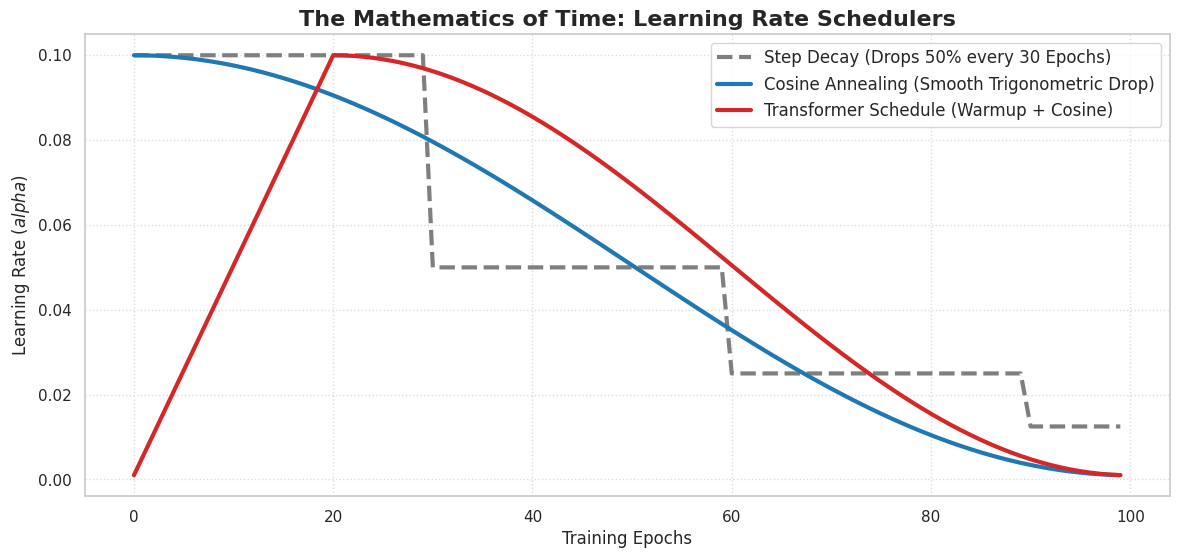

In [4]:
# 1. Setup a dummy model and optimizer
# Schedulers require an optimizer to attach to.
model = nn.Linear(10, 1)
epochs = 100
initial_lr = 0.1

# We create three identical optimizers to test the three strategies
opt_step = optim.AdamW(model.parameters(), lr=initial_lr)
opt_cosine = optim.AdamW(model.parameters(), lr=initial_lr)
opt_warmup = optim.AdamW(model.parameters(), lr=initial_lr)

# 2. Define the Schedulers
# A. Step Decay: Drop by 50% (gamma=0.5) every 30 epochs
scheduler_step = StepLR(opt_step, step_size=30, gamma=0.5)

# B. Cosine Annealing: Smoothly drop to 0.001 over 100 epochs
scheduler_cosine = CosineAnnealingLR(opt_cosine, T_max=epochs, eta_min=0.001)

# C. The Transformer Standard: Linear Warmup followed by Cosine Decay
# Warmup from a factor of 0.01 to 1.0 over the first 20 epochs
warmup = LinearLR(opt_warmup, start_factor=0.01, end_factor=1.0, total_iters=20)
# Then Cosine decay for the remaining 80 epochs
decay = CosineAnnealingLR(opt_warmup, T_max=80, eta_min=0.001)
# Chain them together using SequentialLR
scheduler_transformer = SequentialLR(opt_warmup, schedulers=[warmup, decay], milestones=[20])

# 3. Simulate the Training Loop
lr_history_step = []
lr_history_cosine = []
lr_history_transformer = []

for epoch in range(epochs):
    # Log the current learning rates
    lr_history_step.append(opt_step.param_groups[0]['lr'])
    lr_history_cosine.append(opt_cosine.param_groups[0]['lr'])
    lr_history_transformer.append(opt_warmup.param_groups[0]['lr'])
    
    # Simulate optimizer stepping
    opt_step.step()
    opt_cosine.step()
    opt_warmup.step()
    
    # CRITICAL MLOPS STEP: The scheduler must be stepped AFTER the optimizer!
    scheduler_step.step()
    scheduler_cosine.step()
    scheduler_transformer.step()

# 4. Matplotlib Visualization of the Learning Rate Curves
plt.figure(figsize=(14, 6))

plt.plot(lr_history_step, label='Step Decay (Drops 50% every 30 Epochs)', color='#7f7f7f', linewidth=3, linestyle='--')
plt.plot(lr_history_cosine, label='Cosine Annealing (Smooth Trigonometric Drop)', color='#1f77b4', linewidth=3)
plt.plot(lr_history_transformer, label='Transformer Schedule (Warmup + Cosine)', color='#d62728', linewidth=3)

plt.title("The Mathematics of Time: Learning Rate Schedulers", fontsize=16, fontweight='bold')
plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Learning Rate ($alpha$)", fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

*(Insight: Look closely at the Red line (Transformer Schedule). Notice how it starts near zero, climbs steadily to $0.10$ over the first 20 epochs to stabilize the AdamW averages, and then perfectly rides the Cosine curve down to the floor for hyper-precise convergence. This exact mathematical curve is what allowed OpenAI to train GPT-3 without the network exploding!)*

## Real-World Use Case or Analogy:

Think of Learning Rate Scheduling like **Landing a SpaceX Rocket**:

* **Static Learning Rate (Crash)**: The rocket approaches the landing pad at 500 MPH. It never slows down. It hits the exact center of the pad, but the kinetic energy destroys the rocket (Bouncing around the loss minimum without settling).
* **Step Decay (The Manual Pilot)**: The pilot flies at 500 MPH. At 10,000 feet, they violently slam the brakes, instantly dropping to 250 MPH. At 5,000 feet, they slam the brakes again, dropping to 125 MPH. It works, but the jarring transitions cause massive turbulence and wear on the engines.
* **Cosine Annealing (The Autopilot)**: The rocket calculates a perfectly smooth, parabolic deceleration curve. As the altitude drops, the speed continuously and elegantly bleeds off. By the time the landing gear is 1 inch above the pad, the rocket is moving at 1 MPH, touching down perfectly.
* **Linear Warmup (The Cold Engine Start)**: You cannot instantly ignite a frozen rocket engine to 100% thrust; the combustion chamber will shatter (Exploding Gradients). You must ignite it at 1%, slowly warm the metal up to operating temperatures (Linear Warmup), and *then* push to maximum thrust to begin the descent.